# Who Survived the Titanic? Classification with Machine Learning

<div align='center'>
<img src='https://offloadmedia.feverup.com/secretlosangeles.com/wp-content/uploads/2023/01/13025008/shutterstock_1837038775-1-1024x671.jpg' width='500'>
</div>

## Introduction

Classification is a supervised learning technique used to predict discrete outcomes, such as Yes/No or Survived/Not Survived.

In this project, we analyze the famous Titanic dataset to predict whether a passenger survived or not based on various features such as age, gender, ticket class, and fare. This is one of the most well-known classification problems in data science and serves as a strong foundation for building predictive models.

The dataset consists of 891 observations and 12 features, including both numerical and categorical variables. Some features, such as Age, Cabin, and Embarked, contain missing values, which require proper preprocessing before model training.

By applying data preprocessing, feature engineering, and multiple classification algorithms, we aim to build an accurate model that can effectively predict survival outcomes and uncover key factors that influenced passenger survival.

https://www.kaggle.com/competitions/titanic/data?select=gender_submission.csv

### Importing Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Read Data

In [16]:
df1=pd.read_csv('ttrain.csv')
df2=pd.read_csv('ttest.csv')

### EDA

In [19]:
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
df1.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [21]:
df1.shape

(891, 12)

In [22]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
df1.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
df2.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [25]:
df2.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [26]:
df2.shape

(418, 11)

In [27]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [28]:
df=pd.concat([df1,df2]) # We combined the df1 and df2 datasets.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 132.9+ KB


In [30]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [31]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [32]:
df.Survived.value_counts()

Survived
0.0    549
1.0    342
Name: count, dtype: int64

In [33]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.038354,0.028814,-0.055224,0.008942,0.031428
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.038354,-0.338481,1.000000,-0.408106,0.060832,0.018322,-0.558629
Age,0.028814,-0.077221,-0.408106,1.000000,-0.243699,-0.150917,0.178740
SibSp,-0.055224,-0.035322,0.060832,-0.243699,1.000000,0.373587,0.160238
Parch,0.008942,0.081629,0.018322,-0.150917,0.373587,1.000000,0.221539
Fare,0.031428,0.257307,-0.558629,0.178740,0.160238,0.221539,1.000000


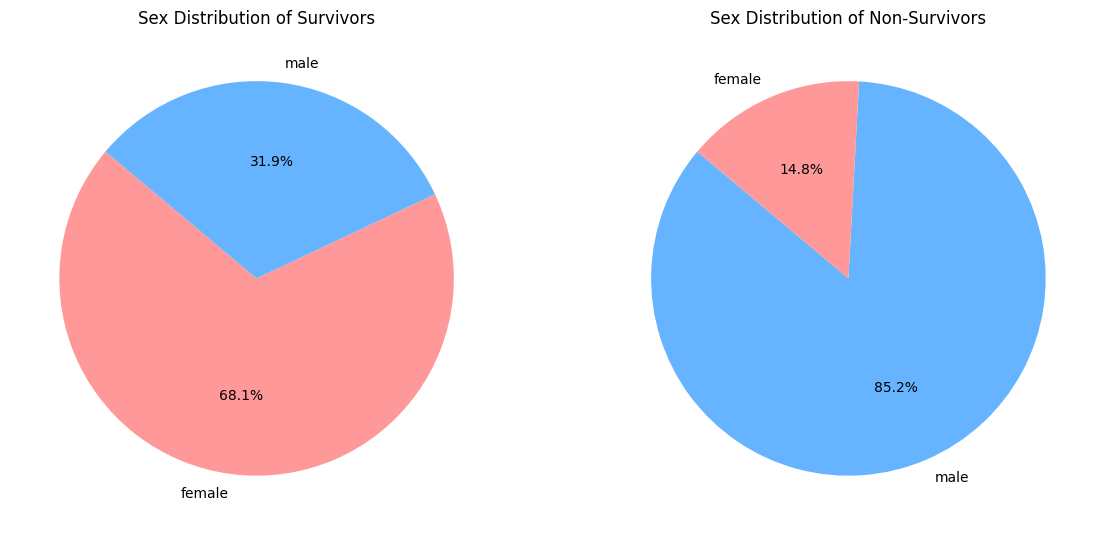

In [34]:
survived_sex_distribution = df[df['Survived'] == 1]['Sex'].value_counts()
not_survived_sex_distribution = df[df['Survived'] == 0]['Sex'].value_counts()

labels_survived = survived_sex_distribution.index
sizes_survived = survived_sex_distribution.values

labels_not_survived = not_survived_sex_distribution.index
sizes_not_survived = not_survived_sex_distribution.values
colors = ['#ff9999', '#66b3ff']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
ax1.pie(sizes_survived, labels=labels_survived, autopct='%1.1f%%', colors=colors, startangle=140)
ax1.set_title('Sex Distribution of Survivors')
colors = ['#66b3ff','#ff9999']

ax2.pie(sizes_not_survived, labels=labels_not_survived, autopct='%1.1f%%', colors=colors, startangle=140)
ax2.set_title('Sex Distribution of Non-Survivors')

plt.show()
plt.show()

In [35]:
# Since 'Embarked' has only 2 missing values and 'Fare' has 1, we can fill them using mean or mode.
# 'Cabin' has too many missing values (1014), so we drop this column.

In [36]:
del df['Cabin']

In [37]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [38]:
df['Fare'].value_counts()

Fare
8.0500     60
13.0000    59
7.7500     55
26.0000    50
7.8958     49
           ..
7.7417      1
8.1583      1
8.4583      1
7.8000      1
7.7208      1
Name: count, Length: 281, dtype: int64

In [39]:
#df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')

In [40]:
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

In [41]:
df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age            263
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [42]:
df['Embarked'].value_counts()

Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [43]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [44]:
df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age            263
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [45]:
df['Title']=df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [46]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr


In [47]:
df['Title'].value_counts()

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Mlle          2
Major         2
Ms            2
Lady          1
Sir           1
Mme           1
Don           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

In [48]:
df['Title']= df['Title'].replace(['Rev','Dr','Col','Major','Sir','Don','Capt','Jonkheer'],'Mr')

In [49]:
df['Title'].value_counts()

Title
Mr          783
Miss        260
Mrs         197
Master       61
Ms            2
Mlle          2
Mme           1
Lady          1
Countess      1
Dona          1
Name: count, dtype: int64

In [50]:
df['Title']= df['Title'].replace(['Lady','Countess','Dona','Mme'],'Mrs')

In [51]:
df['Title'].value_counts()

Title
Mr        783
Miss      260
Mrs       201
Master     61
Ms          2
Mlle        2
Name: count, dtype: int64

In [52]:
df['Title']= df['Title'].replace(['Mlle','Ms'],'Miss')

In [53]:
df['Title'].value_counts()

Title
Mr        783
Miss      264
Mrs       201
Master     61
Name: count, dtype: int64

In [54]:
df['Age']=df['Age'].fillna(df.groupby('Title')['Age'].transform('mean'))

In [55]:
df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Title            0
dtype: int64

In [56]:
del df['Name']

In [57]:
del df['Ticket']

In [58]:
del df['Embarked']

In [59]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Title
0,1,0.0,3,male,22.0,1,0,7.2500,Mr
1,2,1.0,1,female,38.0,1,0,71.2833,Mrs
2,3,1.0,3,female,26.0,0,0,7.9250,Miss
3,4,1.0,1,female,35.0,1,0,53.1000,Mrs
4,5,0.0,3,male,35.0,0,0,8.0500,Mr


In [60]:
df=pd.get_dummies(df,drop_first=True)

In [61]:
df.to_pickle('titanic_n.pkl') #df=pd.read_pickle('kc_house.pkl')

In [62]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Title_Miss,Title_Mr,Title_Mrs
0,1,0.0,3,22.0,1,0,7.2500,True,False,True,False
1,2,1.0,1,38.0,1,0,71.2833,False,False,False,True
2,3,1.0,3,26.0,0,0,7.9250,False,True,False,False
3,4,1.0,1,35.0,1,0,53.1000,False,False,False,True
4,5,0.0,3,35.0,0,0,8.0500,True,False,True,False


In [63]:
df.shape

(1309, 11)

In [64]:
train=df[:891]
test=df[891:]

In [65]:
train.tail()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Title_Miss,Title_Mr,Title_Mrs
886,887,0.0,2,27.000000,0,0,13.00,True,False,True,False
887,888,1.0,1,19.000000,0,0,30.00,False,True,False,False
888,889,0.0,3,21.824366,1,2,23.45,False,True,False,False
889,890,1.0,1,26.000000,0,0,30.00,True,False,True,False
890,891,0.0,3,32.000000,0,0,7.75,True,False,True,False


In [66]:
x=train.drop(['Survived','PassengerId'],axis=1)

In [67]:
y=train[['Survived']]

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [69]:
r=RandomForestClassifier()
g=GradientBoostingClassifier()

In [70]:
r.fit(x,y)

/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
test=test.drop(['PassengerId','Survived'],axis=1)

In [72]:
test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Title_Miss,Title_Mr,Title_Mrs
0,3,34.5,0,0,7.8292,True,False,True,False
1,3,47.0,1,0,7.0000,False,False,False,True
2,2,62.0,0,0,9.6875,True,False,True,False
3,3,27.0,0,0,8.6625,True,False,True,False
4,3,22.0,1,1,12.2875,False,False,False,True


In [73]:
tahmin=r.predict(test)

In [74]:
sonuc=pd.DataFrame()

In [75]:
sonuc

""


In [76]:
sonuc['Survived']=tahmin

In [77]:
sonuc['PassengerId']=df2['PassengerId']

In [78]:
sonuc['Survived']=sonuc['Survived'].astype('int32')

In [79]:
sonuc

,Survived,PassengerId
0,0,892
1,0,893
2,1,894
3,1,895
4,1,896
...,...,...
413,0,1305
414,1,1306
415,0,1307
416,0,1308


In [80]:
sonuc.to_csv('sonuc1.csv',index=False)

In [84]:
g.fit(x,y)

/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [85]:
tahmin1=g.predict(test)

In [86]:
sonuc1=pd.DataFrame()

In [87]:
sonuc1['Survived']=tahmin1

In [88]:
sonuc1['PassengerId']=df2['PassengerId']

In [89]:
sonuc1['Survived']=sonuc1['Survived'].astype('int32')

In [90]:
sonuc1

,Survived,PassengerId
0,0,892
1,0,893
2,0,894
3,0,895
4,1,896
...,...,...
413,0,1305
414,1,1306
415,0,1307
416,0,1308


In [92]:
sonuc1.to_csv('submission.csv',index=False)

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [82]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[86 19]
 [20 54]]
LogisticRegression()  modeli eğitiliyor!..
[[90 15]
 [20 54]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[89 16]
 [22 52]]
RandomForestClassifier()  modeli eğitiliyor!..


/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.

[[91 14]
 [18 56]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[92 13]
 [16 58]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[89 16]
 [32 42]]
AdaBoostClassifier()  modeli eğitiliyor!..


/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[[91 14]
 [19 55]]
MultinomialNB()  modeli eğitiliyor!..
[[92 13]
 [33 41]]
Eğitim tamamlandı.
En başarılı model:  GradientBoostingClassifier
Confusion Matrix:
[[92 13]
 [16 58]]
classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.88      0.86       105
         1.0       0.82      0.78      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

Diğer Modeller:


/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.837989,0.837989,0.837989,0.837989
RandomForestClassifier,0.821229,0.821229,0.821229,0.821229
AdaBoostClassifier,0.815642,0.815642,0.815642,0.815642
LogisticRegression,0.804469,0.804469,0.804469,0.804469
DecisionTreeClassifier,0.787709,0.787709,0.787709,0.787709
BernoulliNB,0.782123,0.782123,0.782123,0.782123
MultinomialNB,0.743017,0.743017,0.743017,0.743017
KNeighborsClassifier,0.731844,0.731844,0.731844,0.731844


### Conclusion

In this project, we applied multiple classification algorithms to predict passenger survival on the Titanic dataset.

Among all models, the Gradient Boosting Classifier achieved the best performance with an accuracy of 83.8%, making it the most effective model for this task. It was closely followed by Random Forest and AdaBoost, which also demonstrated strong predictive capabilities.

Traditional models such as Logistic Regression performed reasonably well, indicating that the dataset contains meaningful patterns that can be captured with both linear and non-linear approaches. However, simpler models like KNN and Naive Bayes showed comparatively lower performance, suggesting that they are less suitable for this problem.

Overall, the results highlight the effectiveness of ensemble learning methods, particularly boosting algorithms, in improving classification performance. With proper preprocessing and feature engineering, it is possible to achieve reliable predictions on real-world datasets like Titanic.